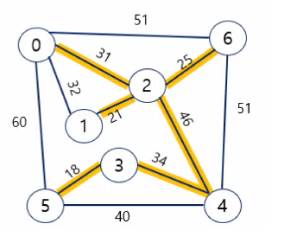

In [2]:
import sys
sys.stdin = open("input_folder/mst_input.txt", "r")

# TODO : x가 속한 집합의 대표찾기 함수
def find_set(x):
    # x의 부모가 자기자신이면(=x가 속한 집합의 대표가 x이면)
    if x == parents[x]:
        # 대표를 리턴
        return x
    # 경로 압축: x의 부모 자리에 x부모의 find_set을 넣는다.
    parents[x] = find_set(parents[x])
    # x부모를 리턴
    return parents[x]

# TODO : x가속한집합, y가속한집합을 합치는 함수
def union(x,y):
    # x의 대표찾고 변수로 두기
    rep_x = find_set(x)
    # y의 대표찾고 변수로 두기
    rep_y = find_set(y)
    # 대표가 같으면 유니온 할 필요 X
    if rep_x == rep_y:
        return
    # 더 작은 대표로 통일해서 병합하기
    if rep_x < rep_y:
        parents[rep_y] = rep_x
    else:
        parents[rep_x] = rep_y
    return        
    

# TODO : V,E 입력받기
V,E = map(int, sys.stdin.readline().split())

# 1. 간선들을 가중치 기준으로 정렬
# TODO : edges 리스트 만들기
edges = []

# TODO : E번 입력 받아 (start,end,weight)를 edges에 담기
for _ in range(E):
    start, end, weight = map(int, sys.stdin.readline().split())
    edges.append((start,end,weight))

# TODO : 가중치 기준 오름차순 정렬
edges.sort(key = lambda x : x[2])


# 2. 가중치가 작은 간선부터 순서대로 선택하자
#  - 사이클이 발생하면 고르지 말자!
#  - 언제까지 ?
#   - MST 가 완성될 때까지
#   - == V-1 개를 선택할 때 까지
# TODO : 현재까지 선택한 간선의 수 cnt 변수로두기
cnt = 0
# TODO : 가중치의 합 result 변수로두기
result = 0
# TODO : make_set: parents 리스트형성
parents = [x for x in range(V)]
# TODO : edges 순회하며 집합 합치기
for u,v,w in edges:
    # u, v가 사이클이 아니라면 유니온하라
    if find_set(u) != find_set(v):
        # union
        union(u,v)
        # cnt 증가
        cnt += 1
        # result 증가
        result += w
        # 종료조건
        if cnt == V-1:
            break

print(f'최소 비용 = {result}')




최소 비용 = 175
